# Telco Customer Churn Analysis and Prediction Using Data Analytics and AI

**Student:** Vinodraj Badigera  
**Internship:** IBM SkillsBuild Data Analytics with AI Academic Internship Program  
**Project Type:** Data Analytics + Machine Learning  
**Notebook:** VinodrajBadigera_TelcoCustomerChurn.ipynb

## Project Objective
The objective of this project is to analyze customer information from a telecommunications company, identify patterns associated with customer churn, visualize important business factors, and build machine-learning models that can predict whether a customer is likely to leave the service.

The project follows a practical analytics workflow:

**Data Collection → Data Cleaning → Exploratory Data Analysis → Visualization → Feature Engineering → Machine Learning → Evaluation → Prediction → Business Insights**

> **Important:** This notebook uses IBM's public Telco Customer Churn sample dataset. The IBM repository contains the dataset and an example end-to-end churn workflow. The repository is archived/read-only, but the dataset remains publicly accessible.


## 1. Business Problem

Customer churn means that an existing customer stops using a company's service. Losing customers can affect revenue and increase the cost of acquiring new customers.

The questions addressed in this project are:

1. What does the customer dataset look like?
2. Are there missing or incorrectly typed values?
3. Which customer characteristics are associated with churn?
4. How do contract type, tenure and monthly charges relate to churn?
5. Can machine learning be used to predict churn?
6. How can the results support customer-retention decisions?

### Project Outcome
The final notebook produces:
- cleaned data,
- descriptive statistics,
- multiple visualizations,
- trained machine-learning models,
- evaluation metrics,
- a confusion matrix,
- feature-importance information,
- and a sample churn-probability prediction.


## 2. Technologies Used

- **Python** – programming language
- **Jupyter Notebook** – interactive development environment
- **Pandas** – data loading and manipulation
- **NumPy** – numerical operations
- **Matplotlib** – visualization
- **Seaborn** – statistical visualization
- **Scikit-learn** – preprocessing, model training and evaluation

The machine-learning part is a classification problem because the target variable has two classes: **Yes (churn)** and **No (not churn)**.


In [1]:
# 3. Import required libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")


Libraries imported successfully.


## 4. Load the Dataset

The dataset is loaded directly from the public IBM GitHub repository. If the CSV file has already been downloaded into the same folder as this notebook, the local file will be used first.

Dataset source:


In [2]:
# Dataset source
DATA_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
LOCAL_FILE = "Telco-Customer-Churn.csv"

try:
    df = pd.read_csv(LOCAL_FILE)
    print("Loaded local dataset:", LOCAL_FILE)
except FileNotFoundError:
    df = pd.read_csv(DATA_URL)
    print("Loaded dataset from IBM public repository.")

print("Dataset loaded successfully.")
print("Shape:", df.shape)


Loaded dataset from IBM public repository.
Dataset loaded successfully.
Shape: (7043, 21)


In [3]:
# Display the first five rows
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Display the last five rows
df.tail()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [5]:
# Basic information about columns and data types
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
# Statistical summary of numerical columns
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 5. Data Cleaning

The dataset contains a `TotalCharges` column that may be read as text because some records contain blank values. We convert it to numeric and let the preprocessing pipeline handle any resulting missing values.

The customer ID is an identifier and is not useful as a predictive feature, so it is removed before modeling.


In [7]:
# Make a working copy
data = df.copy()

# Convert TotalCharges to numeric; invalid/blank values become NaN
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

# Count missing values before preprocessing
missing_before = data.isnull().sum().sort_values(ascending=False)
print("Missing values before preprocessing:")
print(missing_before[missing_before > 0])

# Target distribution
print("\nChurn distribution:")
print(data["Churn"].value_counts())


Missing values before preprocessing:
TotalCharges    11
dtype: int64

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [8]:
# Remove identifier column
data = data.drop(columns=["customerID"])

# Convert target to binary values
data["Churn"] = data["Churn"].map({"No": 0, "Yes": 1})

print("Cleaned data shape:", data.shape)
print("\nTarget values:")
print(data["Churn"].value_counts())


Cleaned data shape: (7043, 20)

Target values:
Churn
0    5174
1    1869
Name: count, dtype: int64


## 6. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is used to understand patterns in the data before machine learning. The following visualizations examine churn distribution, contract type, tenure, monthly charges, and internet service.


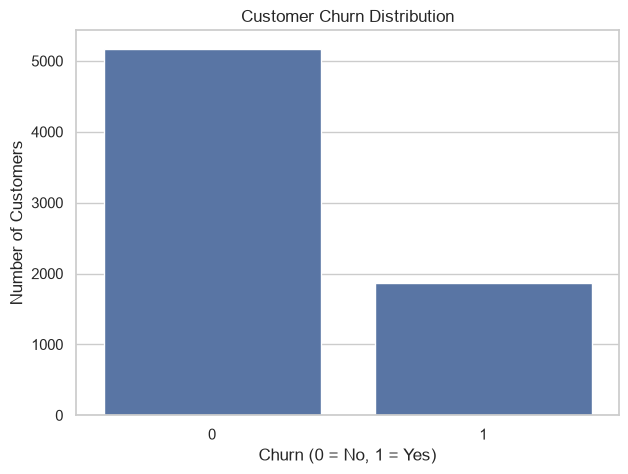

Churn percentage:
26.54 %


In [9]:
# Churn distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=data, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

print("Churn percentage:")
print((data["Churn"].mean() * 100).round(2), "%")


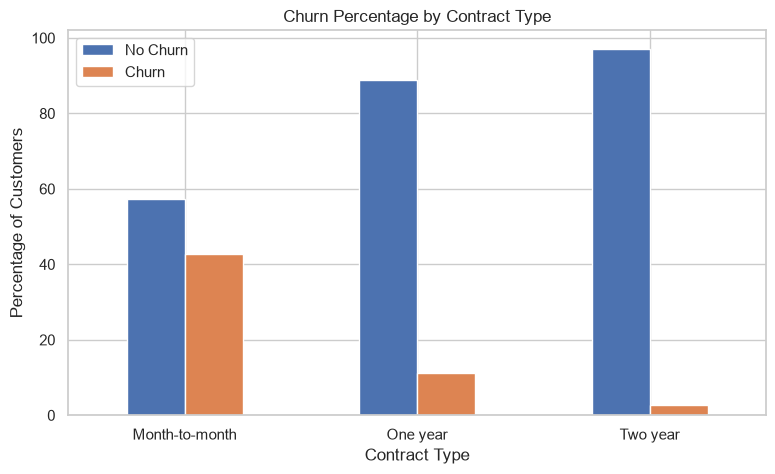

Churn,0,1
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


In [10]:
# Churn by contract type
contract_churn = pd.crosstab(
    data["Contract"],
    data["Churn"],
    normalize="index"
) * 100

contract_churn.plot(kind="bar", figsize=(9, 5))
plt.title("Churn Percentage by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(["No Churn", "Churn"])
plt.show()

display(contract_churn.round(2))


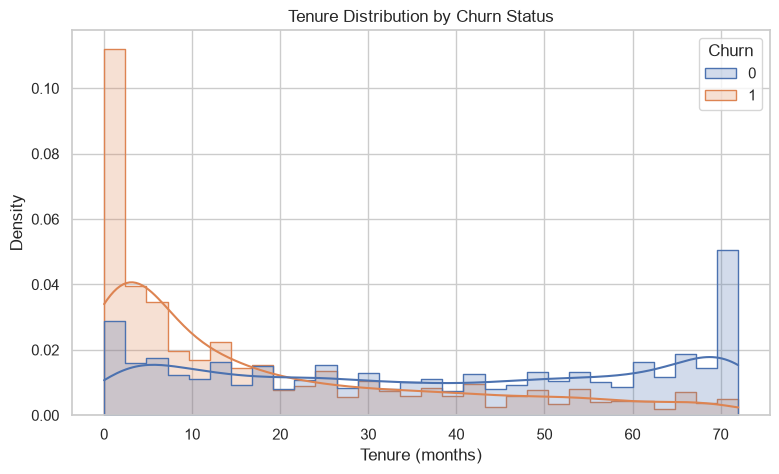

In [11]:
# Tenure distribution by churn status
plt.figure(figsize=(9, 5))
sns.histplot(
    data=data,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)
plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Tenure (months)")
plt.ylabel("Density")
plt.show()


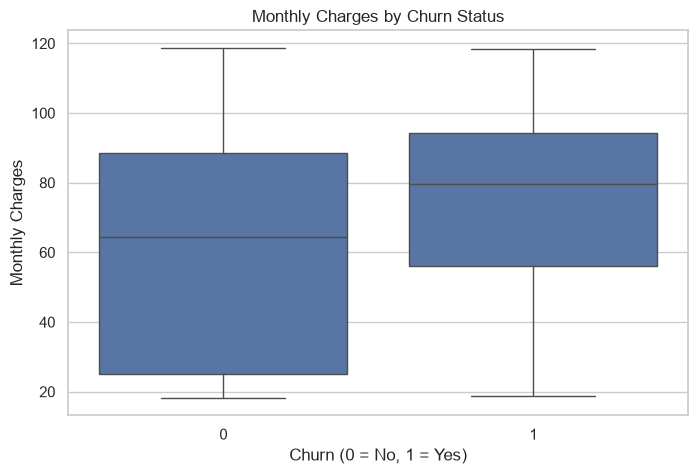

In [12]:
# Monthly charges by churn status
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Monthly Charges")
plt.show()


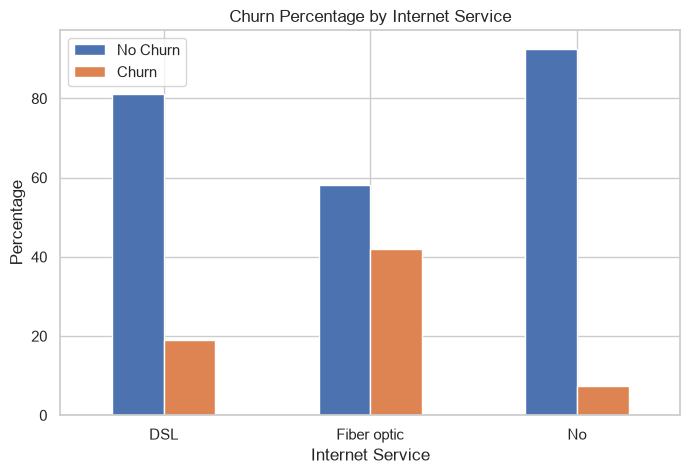

Churn,0,1
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


In [13]:
# Churn percentage by Internet Service
internet_churn = pd.crosstab(
    data["InternetService"],
    data["Churn"],
    normalize="index"
) * 100

internet_churn.plot(kind="bar", figsize=(8, 5))
plt.title("Churn Percentage by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(["No Churn", "Churn"])
plt.show()

display(internet_churn.round(2))


In [14]:
# Average numerical values by churn status
numeric_summary = data.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean()
numeric_summary.index = ["No Churn", "Churn"]
display(numeric_summary.round(2))


,tenure,MonthlyCharges,TotalCharges
No Churn,37.57,61.27,2555.34
Churn,17.98,74.44,1531.80


## 7. Prepare Data for Machine Learning

The target variable is `Churn`.

- `X` contains customer features.
- `y` contains the churn label.
- Numerical columns are imputed and standardized.
- Categorical columns are imputed and one-hot encoded.
- The preprocessing steps are placed inside a scikit-learn pipeline so the same transformations are applied consistently to training and test data.


In [15]:
# Separate features and target
X = data.drop(columns=["Churn"])
y = data["Churn"]

# Identify numerical and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [16]:
# Preprocessing pipelines
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created.")


Preprocessing pipeline created.


In [17]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])


Training records: 5634
Testing records: 1409


## 8. Machine Learning Model 1 — Logistic Regression

Logistic Regression is a common classification algorithm. It estimates the probability of belonging to a class and is useful as an interpretable baseline for binary classification.


In [18]:
# Logistic Regression pipeline
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression model trained successfully.")


Logistic Regression model trained successfully.


## 9. Machine Learning Model 2 — Random Forest

Random Forest is an ensemble classification algorithm that combines many decision trees. It can model nonlinear relationships between customer characteristics and churn.


In [19]:
# Random Forest pipeline
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest model trained successfully.")


Random Forest model trained successfully.


## 10. Model Evaluation

The models are evaluated using:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Because churn is a business-risk problem, it is useful to examine more than accuracy alone.


In [20]:
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

results = pd.DataFrame([
    evaluate_model("Logistic Regression", y_test, logistic_pred, logistic_prob),
    evaluate_model("Random Forest", y_test, rf_pred, rf_prob)
])

display(results.round(4))


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8419
1,Random Forest,0.7658,0.5521,0.6230,0.5854,0.8218


In [21]:
# Detailed classification reports
print("=== Logistic Regression ===")
print(classification_report(
    y_test,
    logistic_pred,
    target_names=["No Churn", "Churn"],
    zero_division=0
))

print("\n=== Random Forest ===")
print(classification_report(
    y_test,
    rf_pred,
    target_names=["No Churn", "Churn"],
    zero_division=0
))


=== Logistic Regression ===
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


=== Random Forest ===
              precision    recall  f1-score   support

    No Churn       0.86      0.82      0.84      1035
       Churn       0.55      0.62      0.59       374

    accuracy                           0.77      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409



# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_log = confusion_matrix(y_test, logistic_pred)
sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
axes[0].set_title("Logistic Regression - Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=axes[1],
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
axes[1].set_title("Random Forest - Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


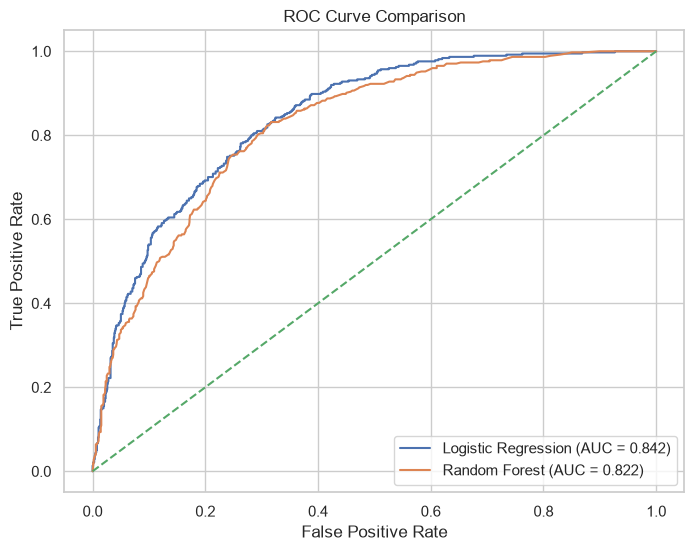

In [22]:
# ROC curves
fpr_log, tpr_log, _ = roc_curve(y_test, logistic_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, logistic_prob):.3f})"
)
plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.3f})"
)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


## 11. Feature Importance

Feature importance helps identify which processed input variables contributed most strongly to the Random Forest model's predictions. The values should be interpreted as model-specific importance, not as proof that a feature causes churn.


In [23]:
# Extract feature names and Random Forest importances
rf_preprocessor = random_forest_model.named_steps["preprocessor"]
rf_classifier = random_forest_model.named_steps["model"]

feature_names = rf_preprocessor.get_feature_names_out()
importances = rf_classifier.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

display(importance_df.head(15).round(4))


,Feature,Importance
3,num__TotalCharges,0.1425
1,num__tenure,0.1323
2,num__MonthlyCharges,0.1223
36,cat__Contract_Month-to-month,0.0723
18,cat__OnlineSecurity_No,0.0366
38,cat__Contract_Two year,0.0365
27,cat__TechSupport_No,0.0311
43,cat__PaymentMethod_Electronic check,0.0290
16,cat__InternetService_Fiber optic,0.0285
21,cat__OnlineBackup_No,0.0167


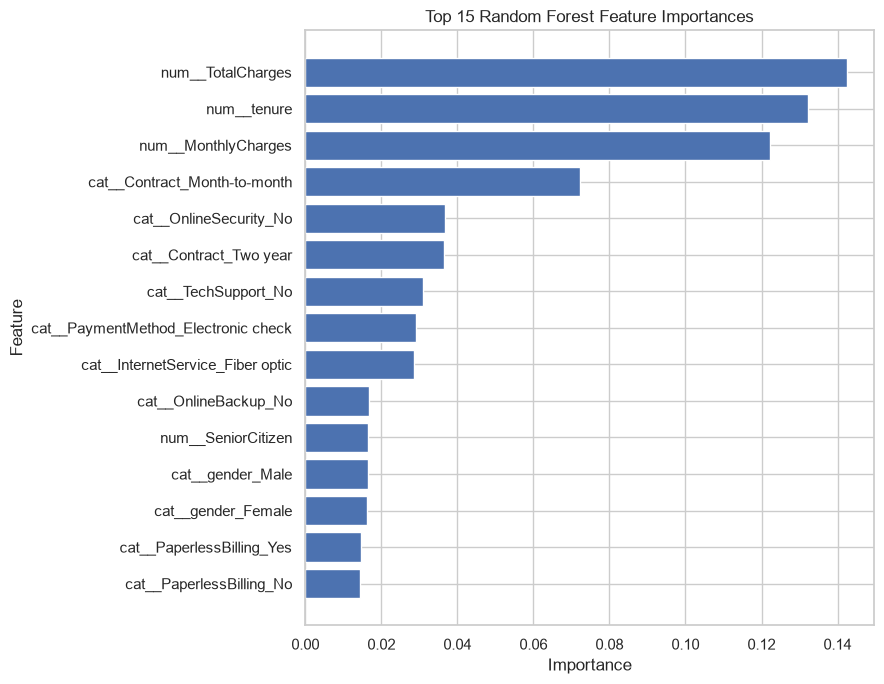

In [24]:
# Plot top 15 feature importances
top_features = importance_df.head(15).sort_values("Importance")

plt.figure(figsize=(9, 7))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 12. Example Prediction

The following section demonstrates how the trained model can estimate churn probability for one customer from the test set.

The probability is a model output, not a guarantee that the customer will churn.


In [25]:
# Example customer from the test set
sample_customer = X_test.iloc[[0]].copy()

prediction = random_forest_model.predict(sample_customer)[0]
probability = random_forest_model.predict_proba(sample_customer)[0, 1]

display(sample_customer)

print("Predicted class:", "Churn" if prediction == 1 else "No Churn")
print(f"Estimated churn probability: {probability:.2%}")


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
437,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.2


Predicted class: No Churn
Estimated churn probability: 0.00%


## 13. Key Analytical Insights

After running all cells, review the charts and outputs and write the most important observations in your own words. Typical questions to answer include:

1. What proportion of customers churned?
2. Which contract type shows a higher churn percentage in this dataset?
3. How does customer tenure differ between churned and non-churned customers?
4. How do monthly charges differ between churned and non-churned customers?
5. Which features have high model importance?
6. What do the precision, recall, F1-score and ROC-AUC indicate?
7. What actions could a telecom company consider for retention?

### Business interpretation
The analysis can support retention teams by identifying customer segments with higher predicted churn risk. A company could use such information to investigate service issues, review contract options, improve customer support, or design targeted retention campaigns. The model should be treated as a decision-support tool rather than an automatic decision maker.


## 14. Conclusion

This project demonstrates an end-to-end Data Analytics and AI workflow using a real-world-style telecom customer churn dataset. The work includes data loading, cleaning, exploratory analysis, visualization, preprocessing, machine-learning classification, evaluation, feature-importance analysis, and example prediction.

The notebook is intentionally reproducible: the train-test split uses `random_state=42`, and the dataset source is documented. Running the notebook from top to bottom generates the numerical evaluation results and visualizations used for the final interpretation.


## 15. Dataset and Reference

**Dataset:** IBM Telco Customer Churn sample dataset  
**Source:** IBM GitHub repository  
**Dataset URL:** {dataset_url}

IBM's repository also provides an example Jupyter Notebook and an end-to-end customer-churn machine-learning workflow.

**Reference:** IBM, `telco-customer-churn-on-icp4d`.
